### Imports & Config

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

CSV_PATH = r"Answers1.csv"


### Load the dataset

In [3]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", len(df.columns))
df.head(3)


Shape: (27, 32)
Columns: 32


,I confirm that I voluntarily agree to participate in this study.,Please create a participant code using the first 2 letters of your mother’s name + the last 2 digits of your phone number (example: DA45).,What is your age?,What is your gender?,"How often do you use food-delivery apps (e.g., Wolt / Uber Eats)?","How often do you use AI chatbots (e.g., ChatGPT / Gemini)?",I generally trust AI systems to provide useful recommendations.,AI systems are reliable in decision-support tasks.,I feel confident relying on AI recommendations when choosing among many options.,I am cautious about trusting AI recommendations.,...,The chatbot is capable of supporting my decision process effectively.,The chatbot performed well in assisting my choice.,"The chatbot provided the information and support I needed to make a good choice (e.g., reflected my preferences/constraints and suggested relevant options).",I can rely on this chatbot.,I trust this chatbot to support my decisions.,I rely on the information provided by this chatbot.,I would use this chatbot feature in a real food-delivery app.,I would use this chatbot again for future food orders.,I would recommend this chatbot feature to others.,Did you follow the chatbot’s top recommendation?
0,I agree,AL57,25-34,Male,Weekly,Weekly,Agree,Agree,Agree,Disagree,...,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Yes
1,I agree,BR02,18-24,Female,Daily,Monthly,Neutral,Agree,Neutral,Neutral,...,Agree,Neutral,Agree,Neutral,Neutral,Neutral,Agree,Agree,Neutral,No
2,I agree,CT19,25-34,Male,Weekly,Daily,Agree,Agree,Agree,Disagree,...,Strongly agree,Agree,Strongly agree,Agree,Agree,Agree,Strongly agree,Agree,Agree,Yes


### Define column names (exact texts)

In [4]:
COLS = {
    # filters / linking
    "consent": "I confirm that I voluntarily agree to participate in this study.",
    "code_pre": "Please create a participant code using the first 2 letters of your mother’s name + the last 2 digits of your phone number (example: DA45).",
    "code_post": "Enter the same participant code you created in the pre-survey.",
    "completed": "Did you complete the chatbot task?",

    # demographics / moderators
    "age": "What is your age?",
    "gender": "What is your gender?",
    "food_freq": "How often do you use food-delivery apps (e.g., Wolt / Uber Eats)?",
    "ai_freq": "How often do you use AI chatbots (e.g., ChatGPT / Gemini)?",

    # baseline trust (pre)
    "pre07": "I generally trust AI systems to provide useful recommendations.",
    "pre08": "AI systems are reliable in decision-support tasks.",
    "pre09": "I feel confident relying on AI recommendations when choosing among many options.",
    "pre10": "I am cautious about trusting AI recommendations.",  # reverse-scored

    # explanation quality (post)
    "post04": "I understood why the chatbot recommended these options.",
    "post05": "The reasoning behind the ranking was clear.",
    "post06": "The explanation was detailed enough for making a decision.",
    "post07": "The explanation helped me evaluate the recommendations.",


    # XAI trust indicators (post)
    "xai_predictable": "The chatbot’s recommendations were predictable.",
    "xai_safe": "I felt safe relying on the chatbot’s recommendations.",
    "xai_calibration": "I knew when I should trust the chatbot’s recommendation and when I should question it.",

    # trust (post) benevolence
    "post08": "The chatbot acted in my best interest.",
    "post09": "The chatbot tried to understand my needs and preferences.",
    "post10": "I felt the chatbot was willing to help me.",

    # trust (post) competence
    "post11": "The chatbot is capable of supporting my decision process effectively.",
    "post12": "The chatbot performed well in assisting my choice.",
    "post13": "The chatbot provided the information and support I needed to make a good choice (e.g., reflected my preferences/constraints and suggested relevant options).",

    # trust (post) reciprocity/reliance
    "post14": "I can rely on this chatbot.",
    "post15": "I trust this chatbot to support my decisions.",
    "post16": "I rely on the information provided by this chatbot.",

    # usage intention (post)
    "post17": "I would use this chatbot feature in a real food-delivery app.",
    "post18": "I would use this chatbot again for future food orders.",
    "post19": "I would recommend this chatbot feature to others.",

    # optional behavior
    "post20": "Did you follow the chatbot’s top recommendation?"
}


### Recoding maps + helper funcs

In [5]:
LIKERT_MAP = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

FREQ_MAP = {"Never": 1, "Rarely": 2, "Monthly": 3, "Weekly": 4, "Daily": 5}
AGE_MAP = {"18-24": 1, "25-34": 2, "35-44": 3, "45+": 4}
GENDER_MAP = {"Male": 1, "Female": 2, "Prefer not to say": 3, "Other": 4}

def to_numeric_likert(s: pd.Series) -> pd.Series:
    return s.map(LIKERT_MAP).astype("float")

def cronbach_alpha(items_df: pd.DataFrame) -> float:
    items_df = items_df.dropna()
    k = items_df.shape[1]
    if k < 2 or len(items_df) == 0:
        return np.nan
    item_vars = items_df.var(axis=0, ddof=1)
    total_var = items_df.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)


### Basic cleaning

In [6]:
df0 = df.copy()

# Consent filter
df0 = df0[df0[COLS["consent"]].astype(str).str.strip().str.lower().eq("i agree")].copy()

# Code match filter (recommended)
if COLS["code_pre"] in df0.columns and COLS["code_post"] in df0.columns:
    df0 = df0[df0[COLS["code_pre"]].astype(str).str.strip() == df0[COLS["code_post"]].astype(str).str.strip()].copy()

# Keep completed or partially completed
df0 = df0[df0[COLS["completed"]].isin(["Yes", "Partially"])].copy()

print("After cleaning:", df0.shape)


After cleaning: (26, 32)


In [7]:
# Cell — diagnose cleaning drops (counts for each filter)
df_raw = df.copy()

consent_ok = df_raw[COLS["consent"]].astype(str).str.strip().str.lower().eq("i agree")
code_match_ok = df_raw[COLS["code_pre"]].astype(str).str.strip() == df_raw[COLS["code_post"]].astype(str).str.strip()
completed_ok = df_raw[COLS["completed"]].isin(["Yes", "Partially"])

print("Total:", len(df_raw))
print("Consent OK:", consent_ok.sum())
print("Code match OK:", code_match_ok.sum())
print("Completed Yes/Partially:", completed_ok.sum())

# show rows that fail any condition
failed = df_raw[~(consent_ok & code_match_ok & completed_ok)]
print("\nDropped rows:", len(failed))
display(failed[[COLS["consent"], COLS["code_pre"], COLS["code_post"], COLS["completed"]]])

Total: 27
Consent OK: 27
Code match OK: 27
Completed Yes/Partially: 26

Dropped rows: 1


,I confirm that I voluntarily agree to participate in this study.,Please create a participant code using the first 2 letters of your mother’s name + the last 2 digits of your phone number (example: DA45).,Enter the same participant code you created in the pre-survey.,Did you complete the chatbot task?
19,I agree,TD96,TD96,No


### Recode & create construct scores

In [8]:
d = df0.copy()

# Moderators/covariates
d["Age_num"] = d[COLS["age"]].map(AGE_MAP).astype("float")
d["Gender_num"] = d[COLS["gender"]].map(GENDER_MAP).astype("float")
d["FoodAppUse_num"] = d[COLS["food_freq"]].map(FREQ_MAP).astype("float")
d["ChatbotUse_num"] = d[COLS["ai_freq"]].map(FREQ_MAP).astype("float")

# Baseline trust
d["Pre07"] = to_numeric_likert(d[COLS["pre07"]])
d["Pre08"] = to_numeric_likert(d[COLS["pre08"]])
d["Pre09"] = to_numeric_likert(d[COLS["pre09"]])
d["Pre10_raw"] = to_numeric_likert(d[COLS["pre10"]])
d["Pre10_rev"] = 6 - d["Pre10_raw"]

d["BaselineTrust"] = d[["Pre07", "Pre08", "Pre09", "Pre10_rev"]].mean(axis=1)

# Explanation quality
d["Post04"] = to_numeric_likert(d[COLS["post04"]])
d["Post05"] = to_numeric_likert(d[COLS["post05"]])
d["Post06"] = to_numeric_likert(d[COLS["post06"]])
d["Post07"] = to_numeric_likert(d[COLS["post07"]])

d["ExplanationQuality"] = d[["Post04","Post05","Post06","Post07"]].mean(axis=1)

# XAI trust indicators (predictability, safety, calibration)
d["XAI_Predictable"] = to_numeric_likert(d[COLS["xai_predictable"]])
d["XAI_Safe"] = to_numeric_likert(d[COLS["xai_safe"]])
d["XAI_Calibration"] = to_numeric_likert(d[COLS["xai_calibration"]])

d["XAIIndicators"] = d[["XAI_Predictable","XAI_Safe","XAI_Calibration"]].mean(axis=1)


# Trust dimensions
for k in ["post08","post09","post10","post11","post12","post13","post14","post15","post16"]:
    d[k.upper()] = to_numeric_likert(d[COLS[k]])

d["Benevolence"] = d[["POST08","POST09","POST10"]].mean(axis=1)
d["Competence"]  = d[["POST11","POST12","POST13"]].mean(axis=1)
d["Reciprocity"] = d[["POST14","POST15","POST16"]].mean(axis=1)
d["TrustTotal"]  = d[["Benevolence","Competence","Reciprocity"]].mean(axis=1)

# Usage intention
d["Post17"] = to_numeric_likert(d[COLS["post17"]])
d["Post18"] = to_numeric_likert(d[COLS["post18"]])
d["Post19"] = to_numeric_likert(d[COLS["post19"]])
d["UsageIntention"] = d[["Post17","Post18","Post19"]].mean(axis=1)

# Optional behavior
if COLS["post20"] in d.columns:
    d["FollowTopRec_bin"] = d[COLS["post20"]].map({"Yes":1, "No":0}).astype("float")

d[["BaselineTrust","ExplanationQuality", "XAIIndicators", "TrustTotal","UsageIntention"]].head()


,BaselineTrust,ExplanationQuality,XAIIndicators,TrustTotal,UsageIntention
0,4.00,3.75,4.000000,4.000000,4.000000
1,3.25,3.50,3.333333,3.333333,3.666667
2,4.00,4.50,4.333333,4.222222,4.333333
3,2.75,2.75,3.333333,3.000000,3.000000
4,4.75,4.75,5.000000,4.777778,5.000000


In [9]:
# Check ranges and missing values for composite scores
score_cols = ["BaselineTrust", "ExplanationQuality", "XAIIndicators", "TrustTotal", "UsageIntention"]
print(d[score_cols].isna().sum())
print("\nMin/Max:")
print(d[score_cols].agg(["min","max"]))

BaselineTrust         0
ExplanationQuality    0
XAIIndicators         0
TrustTotal            0
UsageIntention        0
dtype: int64

Min/Max:
     BaselineTrust  ExplanationQuality  XAIIndicators  TrustTotal  \
min           2.50                2.75       2.666667    3.000000   
max           4.75                4.75       5.000000    4.777778   

     UsageIntention  
min             3.0  
max             5.0  


### Reliability (Cronbach α)

In [10]:

alpha_baseline = cronbach_alpha(d[["Pre07","Pre08","Pre09","Pre10_rev"]])
alpha_expl = cronbach_alpha(d[["Post04","Post05","Post06","Post07"]])
alpha_trust = cronbach_alpha(d[["POST08","POST09","POST10","POST11","POST12","POST13","POST14","POST15","POST16"]])
alpha_usage = cronbach_alpha(d[["Post17","Post18","Post19"]])
alpha_xai = cronbach_alpha(d[["XAI_Predictable","XAI_Safe","XAI_Calibration"]])

print("Cronbach alpha:")
print(f"  BaselineTrust (4 items):      {alpha_baseline:.3f}")
print(f"  ExplanationQuality (4 items): {alpha_expl:.3f}")
print(f"  TrustTotal (9 items):         {alpha_trust:.3f}")
print(f"  UsageIntention (3 items):     {alpha_usage:.3f}")
print(f"  XAIIndicators (3 items):      {alpha_xai:.3f}")


Cronbach alpha:
  BaselineTrust (4 items):      0.896
  ExplanationQuality (4 items): 0.911
  TrustTotal (9 items):         0.975
  UsageIntention (3 items):     0.896
  XAIIndicators (3 items):      0.672


### RQ1

#### TrustTotal ~ ExplanationQuality (+ controls)

In [11]:
rq1 = smf.ols("TrustTotal ~ ExplanationQuality + BaselineTrust + ChatbotUse_num + FoodAppUse_num", data=d).fit(cov_type="HC3")

print(rq1.summary())

                            OLS Regression Results                            
Dep. Variable:             TrustTotal   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     73.96
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.55e-12
Time:                        09:10:12   Log-Likelihood:                 11.088
No. Observations:                  26   AIC:                            -12.18
Df Residuals:                      21   BIC:                            -5.886
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8209      0

#### Correlation

In [12]:
print("corr(ExplanationQuality, BaselineTrust) =",
      d["ExplanationQuality"].corr(d["BaselineTrust"]))

corr(ExplanationQuality, BaselineTrust) = 0.9363593557849852


#### VIF for RQ1 predictors

In [13]:
X = d[["ExplanationQuality", "BaselineTrust", "ChatbotUse_num", "FoodAppUse_num"]].dropna()
X = sm.add_constant(X)

vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

              feature        VIF
0               const  53.254282
1  ExplanationQuality   9.457916
2       BaselineTrust   9.364516
3      ChatbotUse_num   2.671474
4      FoodAppUse_num   1.602422


#### Plots for RQ1

##### Scatter + fit line

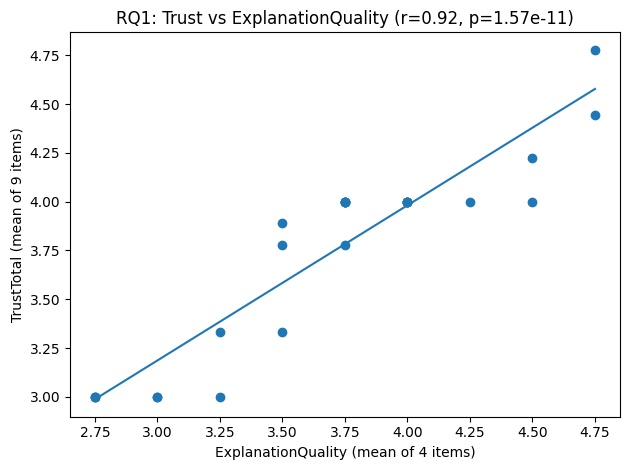

In [14]:
x = d["ExplanationQuality"].values
y = d["TrustTotal"].values

slope, intercept, r, p, _ = stats.linregress(x, y)

plt.figure()
plt.scatter(x, y)
x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(x_line, intercept + slope * x_line)
plt.xlabel("ExplanationQuality (mean of 4 items)")
plt.ylabel("TrustTotal (mean of 9 items)")
plt.title(f"RQ1: Trust vs ExplanationQuality (r={r:.2f}, p={p:.3g})")
plt.tight_layout()
plt.show()


##### Partial relationship

Partial r = 0.36793027987338756 p = 0.06441545060017319


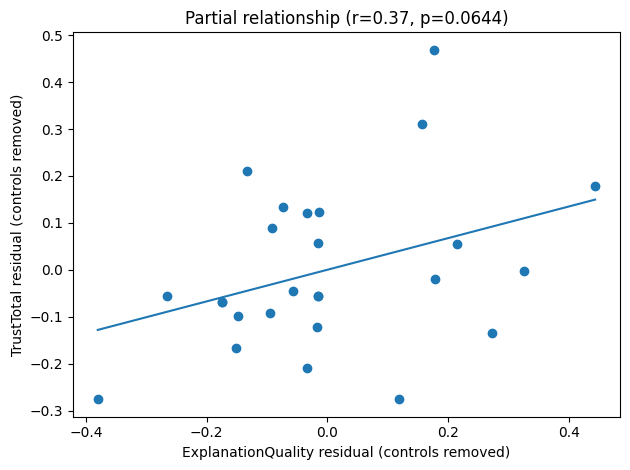

In [15]:
# residualize TrustTotal on controls
m_y = smf.ols("TrustTotal ~ BaselineTrust + ChatbotUse_num + FoodAppUse_num", data=d).fit()
y_res = m_y.resid

# residualize ExplanationQuality on controls
m_x = smf.ols("ExplanationQuality ~ BaselineTrust + ChatbotUse_num + FoodAppUse_num", data=d).fit()
x_res = m_x.resid

r_partial = np.corrcoef(x_res, y_res)[0,1]
p_partial = stats.pearsonr(x_res, y_res).pvalue
print("Partial r =", r_partial, "p =", p_partial)

plt.figure()
plt.scatter(x_res, y_res)
slope, intercept, r, p, _ = stats.linregress(x_res, y_res)
xx = np.linspace(x_res.min(), x_res.max(), 100)
plt.plot(xx, intercept + slope*xx)
plt.xlabel("ExplanationQuality residual (controls removed)")
plt.ylabel("TrustTotal residual (controls removed)")
plt.title(f"Partial relationship (r={r:.2f}, p={p:.3g})")
plt.tight_layout()
plt.show()

### RQ2

#### UsageIntention ~ TrustTotal

In [16]:
# Overall TrustTotal predicting UsageIntention
rq2_total = smf.ols("UsageIntention ~ TrustTotal", data=d).fit(cov_type="HC3")
print(rq2_total.summary())

                            OLS Regression Results                            
Dep. Variable:         UsageIntention   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     533.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.61e-18
Time:                        09:10:13   Log-Likelihood:                 13.681
No. Observations:                  26   AIC:                            -23.36
Df Residuals:                      24   BIC:                            -20.85
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1071      0.171     -0.628      0.5

#### Plot (simple regression line)

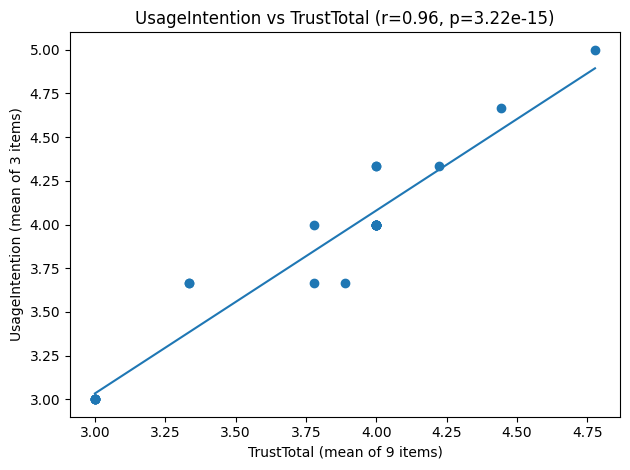

In [17]:
# TrustTotal vs UsageIntention
x = d["TrustTotal"].values
y = d["UsageIntention"].values
slope, intercept, r, p, _ = stats.linregress(x, y)

plt.figure()
plt.scatter(x, y)
xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(xx, intercept + slope * xx)
plt.xlabel("TrustTotal (mean of 9 items)")
plt.ylabel("UsageIntention (mean of 3 items)")
plt.title(f"UsageIntention vs TrustTotal (r={r:.2f}, p={p:.3g})")
plt.tight_layout()
plt.show()

#### UsageIntention ~ Trust dimensions

In [18]:
rq2 = smf.ols("UsageIntention ~ Benevolence + Competence + Reciprocity", data=d).fit(cov_type="HC3")

print(rq2.summary())

                            OLS Regression Results                            
Dep. Variable:         UsageIntention   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     855.4
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.44e-23
Time:                        09:10:14   Log-Likelihood:                 21.064
No. Observations:                  26   AIC:                            -34.13
Df Residuals:                      22   BIC:                            -29.10
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.1917      0.123     -1.552      

#### Multicollinearity diagnostics

In [19]:
X = d[["Benevolence", "Competence", "Reciprocity"]].dropna()
X = sm.add_constant(X)

vif = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

       feature        VIF
0        const  71.224029
1  Benevolence  61.504808
2   Competence   8.818011
3  Reciprocity  40.235108


In [20]:
print(d[["Benevolence","Competence","Reciprocity","UsageIntention"]].corr())

                Benevolence  Competence  Reciprocity  UsageIntention
Benevolence        1.000000    0.929991     0.985083        0.946995
Competence         0.929991    1.000000     0.890762        0.969907
Reciprocity        0.985083    0.890762     1.000000        0.906778
UsageIntention     0.946995    0.969907     0.906778        1.000000


#### Standardized betas

In [21]:
d_std = d.copy()
for c in ["UsageIntention","Benevolence","Competence","Reciprocity"]:
    d_std[c+"_z"] = zscore(d_std[c])

rq3_std = smf.ols(
    "UsageIntention_z ~ Benevolence_z + Competence_z + Reciprocity_z",
    data=d_std
).fit(cov_type="HC3")

betas = rq3_std.params.drop("Intercept")
print("Standardized betas (RQ2):")
print(betas)

Standardized betas (RQ2):
Benevolence_z    0.769161
Competence_z     0.589657
Reciprocity_z   -0.376153
dtype: float64


#### plot (bar chart)

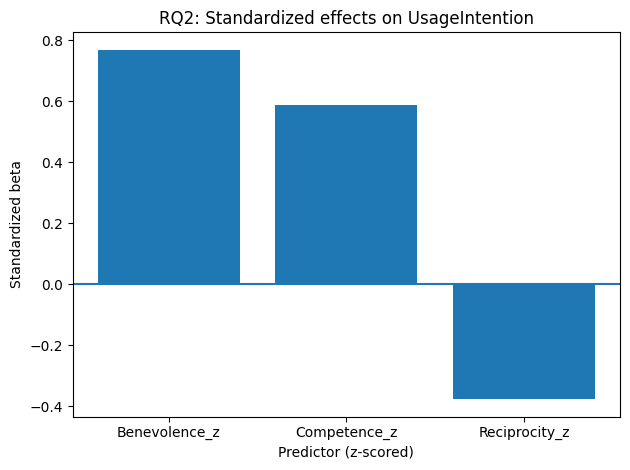

In [22]:
plt.figure()
plt.bar(betas.index, betas.values)
plt.axhline(0)
plt.xlabel("Predictor (z-scored)")
plt.ylabel("Standardized beta")
plt.title("RQ2: Standardized effects on UsageIntention")
plt.tight_layout()
plt.show()

### RQ5

#### Moderation: does Z change Expl->Trust link?

In [24]:
# Center for clean interactions
d["ExplanationQuality_c"] = d["ExplanationQuality"] - d["ExplanationQuality"].mean()

moderators = ["BaselineTrust", "ChatbotUse_num", "FoodAppUse_num"]

models = {}
for Z in moderators:
    d[f"{Z}_c"] = d[Z] - d[Z].mean()
    d[f"Int_{Z}"] = d["ExplanationQuality_c"] * d[f"{Z}_c"]

    m = smf.ols(
        f"TrustTotal ~ ExplanationQuality_c + {Z}_c + Int_{Z}",
        data=d
    ).fit(cov_type="HC3")
    models[Z] = m
    print("\n==============================")
    print(f"RQ5 moderation with {Z}")
    print(m.summary())


RQ5 moderation with BaselineTrust
                            OLS Regression Results                            
Dep. Variable:             TrustTotal   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     138.5
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.97e-14
Time:                        09:10:39   Log-Likelihood:                 12.220
No. Observations:                  26   AIC:                            -16.44
Df Residuals:                      22   BIC:                            -11.41
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

#### Adjusted-moderation model

In [31]:
# Moderation models controlling for BaselineTrust
d["BaselineTrust_c"] = d["BaselineTrust"] - d["BaselineTrust"].mean()
d["ExplanationQuality_c"] = d["ExplanationQuality"] - d["ExplanationQuality"].mean()

for Z in ["ChatbotUse_num", "FoodAppUse_num"]:
    d[f"{Z}_c"] = d[Z] - d[Z].mean()
    d[f"Int_{Z}"] = d["ExplanationQuality_c"] * d[f"{Z}_c"]

    m_adj = smf.ols(
        f"TrustTotal ~ ExplanationQuality_c + {Z}_c + BaselineTrust_c + Int_{Z}",
        data=d
    ).fit(cov_type="HC3")
    print("\nAdjusted moderation with", Z)
    print(m_adj.summary())


Adjusted moderation with ChatbotUse_num
                            OLS Regression Results                            
Dep. Variable:             TrustTotal   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     45.25
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.95e-10
Time:                        09:20:49   Log-Likelihood:                 13.547
No. Observations:                  26   AIC:                            -17.09
Df Residuals:                      21   BIC:                            -10.80
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

#### Plots

##### BaselineTrust simple slopes

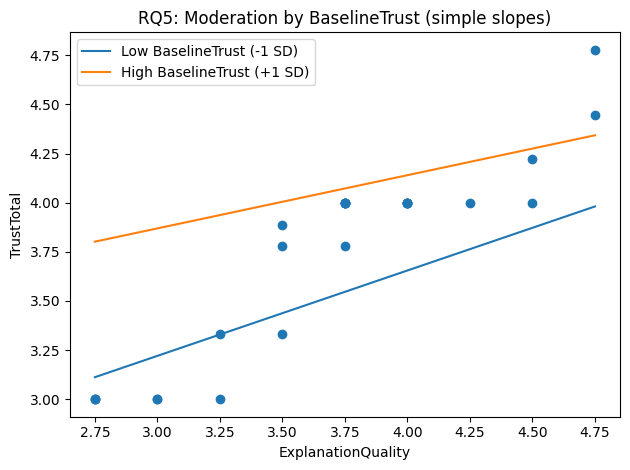

In [25]:
Z = "BaselineTrust"
m = models[Z]

x_vals = np.linspace(d["ExplanationQuality_c"].min(), d["ExplanationQuality_c"].max(), 100)
Z_sd = d[f"{Z}_c"].std(ddof=0)

b0 = m.params["Intercept"]
b1 = m.params["ExplanationQuality_c"]
b2 = m.params[f"{Z}_c"]
b3 = m.params[f"Int_{Z}"]

def pred(xc, zc):
    return b0 + b1*xc + b2*zc + b3*(xc*zc)

y_low = pred(x_vals, -Z_sd)
y_high = pred(x_vals, +Z_sd)

plt.figure()
plt.plot(x_vals + d["ExplanationQuality"].mean(), y_low, label=f"Low {Z} (-1 SD)")
plt.plot(x_vals + d["ExplanationQuality"].mean(), y_high, label=f"High {Z} (+1 SD)")
plt.scatter(d["ExplanationQuality"], d["TrustTotal"])
plt.xlabel("ExplanationQuality")
plt.ylabel("TrustTotal")
plt.title("RQ5: Moderation by BaselineTrust (simple slopes)")
plt.legend()
plt.tight_layout()
plt.show()


##### Forest of interaction coefficients

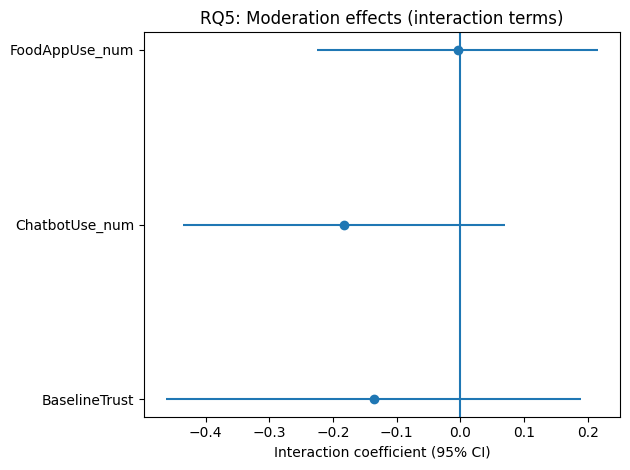

In [33]:
# Forest plot of interaction coefficients (95% CI)

interaction_names = {
    "BaselineTrust": "Int_BaselineTrust",
    "ChatbotUse_num": "Int_ChatbotUse_num",
    "FoodAppUse_num": "Int_FoodAppUse_num",
}

labels = []
effects = []
ci_low = []
ci_high = []

for Z, int_name in interaction_names.items():
    m = models[Z]  # your existing dict: models[moderator] = fitted model
    b = m.params[int_name]
    lo, hi = m.conf_int().loc[int_name].tolist()

    labels.append(Z)
    effects.append(b)
    ci_low.append(lo)
    ci_high.append(hi)

y = np.arange(len(labels))

plt.figure()
plt.axvline(0)
plt.errorbar(
    effects, y,
    xerr=[np.array(effects) - np.array(ci_low), np.array(ci_high) - np.array(effects)],
    fmt='o'
)
plt.yticks(y, labels)
plt.xlabel("Interaction coefficient (95% CI)")
plt.title("RQ5: Moderation effects (interaction terms)")
plt.tight_layout()
plt.show()

#### XAI trust indicators

##### XAIIndicators ~ ExplanationQuality + TrustTotal

In [28]:
# XAIIndicators predicted by ExplanationQuality and TrustTotal
xai_model = smf.ols("XAIIndicators ~ ExplanationQuality + TrustTotal", data=d).fit(cov_type="HC3")
print(xai_model.summary())

                            OLS Regression Results                            
Dep. Variable:          XAIIndicators   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     40.28
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.06e-08
Time:                        09:14:02   Log-Likelihood:                0.95202
No. Observations:                  26   AIC:                             4.096
Df Residuals:                      23   BIC:                             7.870
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.1974      0

##### Correlations

In [26]:
corr_vars = d[["ExplanationQuality","TrustTotal","XAIIndicators"]].corr(method="pearson")
corr_vars

,ExplanationQuality,TrustTotal,XAIIndicators
ExplanationQuality,1.000000,0.924335,0.909061
TrustTotal,0.924335,1.000000,0.891518
XAIIndicators,0.909061,0.891518,1.000000


##### Plot: XAIIndicators vs ExplanationQuality

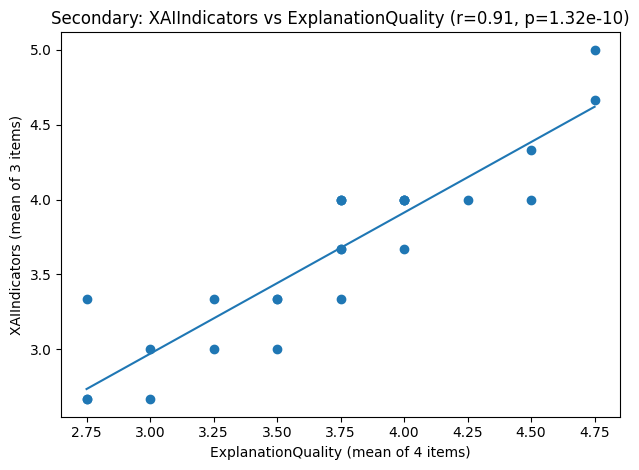

In [29]:
x = d["ExplanationQuality"].values
y = d["XAIIndicators"].values

slope, intercept, r, p, _ = stats.linregress(x, y)

plt.figure()
plt.scatter(x, y)
x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
plt.plot(x_line, intercept + slope * x_line)
plt.xlabel("ExplanationQuality (mean of 4 items)")
plt.ylabel("XAIIndicators (mean of 3 items)")
plt.title(f"Secondary: XAIIndicators vs ExplanationQuality (r={r:.2f}, p={p:.3g})")
plt.tight_layout()
plt.show()

### Descriptive

In [34]:
desc = d[[
    "BaselineTrust","ExplanationQuality","TrustTotal",
    "Benevolence","Competence","Reciprocity",
    "UsageIntention","ChatbotUse_num","FoodAppUse_num"
]].describe().T[["mean","std","min","max"]]

desc

,mean,std,min,max
BaselineTrust,3.586538,0.612137,2.50,4.750000
ExplanationQuality,3.711538,0.581774,2.75,4.750000
TrustTotal,3.752137,0.500180,3.00,4.777778
Benevolence,3.730769,0.480918,3.00,4.666667
Competence,3.820513,0.543493,3.00,5.000000
Reciprocity,3.705128,0.510572,3.00,4.666667
UsageIntention,3.820513,0.543493,3.00,5.000000
ChatbotUse_num,3.807692,0.980581,2.00,5.000000
FoodAppUse_num,4.153846,0.674822,3.00,5.000000


### Save cleaned CSV

In [35]:

OUT_CLEAN = r"Answers1_clean_with_scores_and_xai.csv"
d.to_csv(OUT_CLEAN, index=False)
print("Saved:", OUT_CLEAN)


Saved: Answers1_clean_with_scores_and_xai.csv
